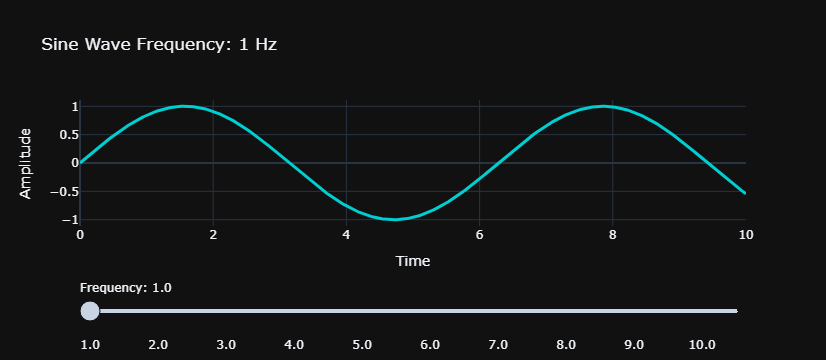

In [4]:
import plotly.graph_objects as go
import numpy as np

# 1. Setup data
x = np.linspace(0, 10, 500)
frequencies = np.arange(1, 11, 0.5)  # Frequencies from 1 to 10

# 2. Create the figure
fig = go.Figure()

# 3. Add a trace for each frequency
# We set visible=False by default for all except the first one
for i, f in enumerate(frequencies):
    fig.add_trace(
        go.Scatter(
            visible=False,
            line=dict(color="#00CED1", width=3),
            name=f"f = {f}",
            x=x,
            y=np.sin(f * x)
        )
    )

# Make the first trace visible
fig.data[0].visible = True

# 4. Create the slider steps
steps = []
for i in range(len(fig.data)):
    step = dict(
        method="update",
        args=[{"visible": [False] * len(fig.data)},
              {"title": f"Sine Wave Frequency: {frequencies[i]} Hz"}],
        label=str(frequencies[i])
    )
    step["args"][0]["visible"][i] = True  # Toggle i'th trace to "visible"
    steps.append(step)

# 5. Create and add the slider to the layout
sliders = [dict(
    active=0,
    currentvalue={"prefix": "Frequency: "},
    pad={"t": 50},
    steps=steps
)]

fig.update_layout(
    sliders=sliders,
    title="Sine Wave Frequency: 1 Hz",
    xaxis_title="Time",
    yaxis_title="Amplitude",
    template="plotly_dark"
)

fig.write_html('interactive_sine.html')
fig.show()